# Customer Segmentation with RFM + K-Means

Segments customers from the UCI **Online Retail** transaction dataset using
**RFM analysis** (Recency, Frequency, Monetary value) and **K-Means clustering**,
so a business can target each group with a different strategy (win-back
campaigns, loyalty perks, VIP treatment, etc).

**Pipeline:** clean transactions -> engineer RFM features per customer ->
scale -> choose k (elbow + silhouette) -> cluster -> label segments by their
actual RFM profile -> summarise revenue and size per segment.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


## 1. Load & clean the raw transactions

In [2]:
df = pd.read_csv('../data/raw/online_retail.csv', encoding='ISO-8859-1')
print(df.shape)
df.head()


(541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,1/12/2010 8:26,2.55,17850.0,India
1,536365,71053,WHITE METAL LANTERN,6,1/12/2010 8:26,3.39,17850.0,India
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,1/12/2010 8:26,2.75,17850.0,India
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,1/12/2010 8:26,3.39,17850.0,India
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,1/12/2010 8:26,3.39,17850.0,India


In [3]:
# Missing values
df.isnull().sum()


Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [4]:
# Drop rows without a customer id or description - can't attribute or don't know what was sold
df = df.dropna(subset=['Customer ID', 'Description'])
df = df.drop_duplicates()

# Keep genuine sales only (positive quantity and price). Negative quantities
# are returns/cancellations - out of scope for this segmentation.
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed', dayfirst=True)
df['Revenue'] = df['Quantity'] * df['Price']
df['Customer ID'] = df['Customer ID'].astype(int)

print(f'{len(df):,} clean transaction rows, {df["Customer ID"].nunique():,} customers')
df.head()


392,693 clean transaction rows, 4,338 customers


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,India,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,India,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,India,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,India,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,India,20.34


## 2. Engineer RFM features (one row per customer)

In [5]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum'),
    Country=('Country', 'first'),
).reset_index()

rfm = rfm[rfm['Monetary'] > 0].reset_index(drop=True)
rfm.describe()


,Customer ID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.692230
std,1721.808492,100.014169,7.697998,8985.229676
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


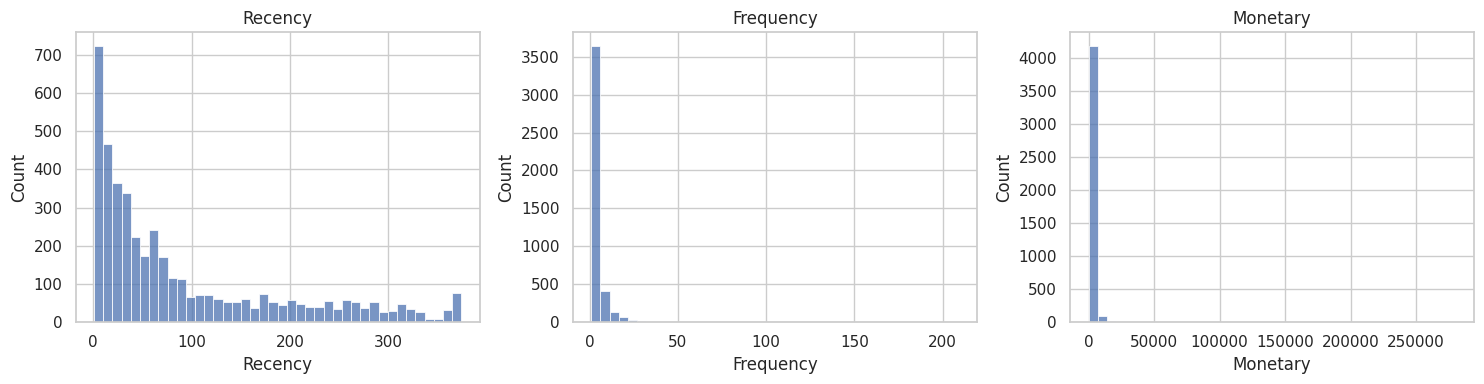

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 3. Scale features and choose k

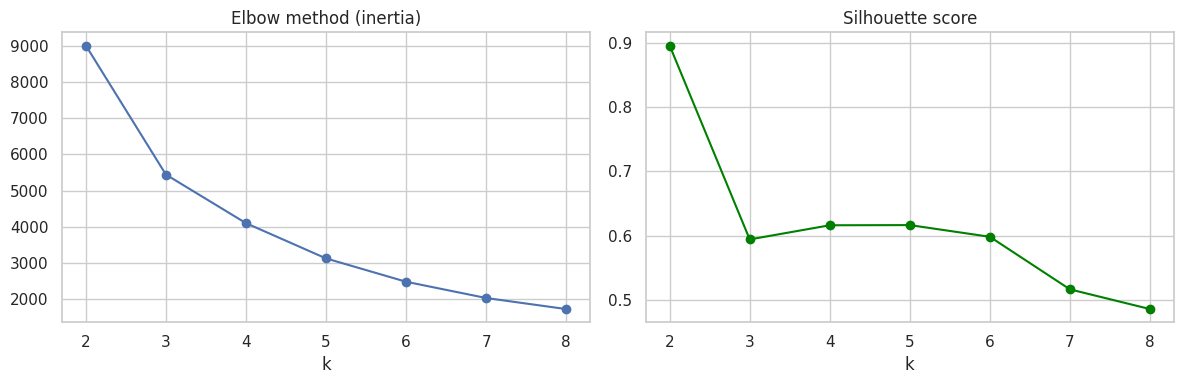

In [7]:
features = rfm[['Recency', 'Frequency', 'Monetary']]
X_scaled = StandardScaler().fit_transform(features)

inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow method (inertia)')
axes[0].set_xlabel('k')

axes[1].plot(list(k_range), sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.savefig('../assets/k_selection.png', dpi=120)
plt.show()


k=4 is chosen: it keeps a strong silhouette score while giving four
segments that map cleanly onto a marketing strategy (Champions, Loyal,
New/Low-Value, At Risk).

## 4. Cluster with K-Means

Silhouette score (k=4): 0.6162


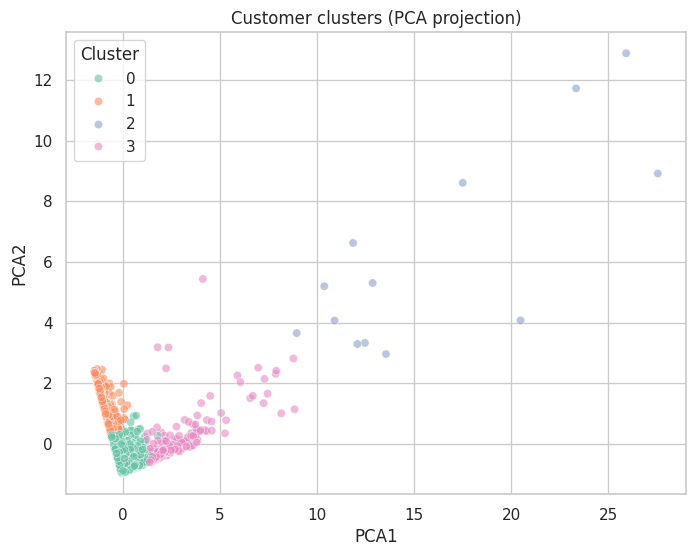

In [8]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, rfm['Cluster'])
print(f'Silhouette score (k=4): {sil:.4f}')

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
rfm['PCA1'], rfm['PCA2'] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', alpha=0.6)
plt.title('Customer clusters (PCA projection)')
plt.savefig('../assets/pca_clusters.png', dpi=120)
plt.show()


## 5. Label segments by their actual RFM profile

Rather than assuming cluster order, each cluster is profiled on average
Recency/Frequency/Monetary and named accordingly - this matters, because a
cluster ranked 3rd by spend could still be *recently active* (low-value but
new) or *long dormant* (at risk), and those need very different strategies.

In [9]:
profile = rfm.groupby('Cluster').agg(Monetary=('Monetary','mean'), Recency=('Recency','mean'), Frequency=('Frequency','mean'))
n = profile.shape[0]
money_rank = profile['Monetary'].rank(ascending=False)
top_half = money_rank[money_rank <= n / 2].index
bottom_half = money_rank[money_rank > n / 2].index

label_map = {}
top_sorted = profile.loc[top_half].sort_values('Monetary', ascending=False).index
for i, cid in enumerate(top_sorted):
    label_map[cid] = 'Champions (VIP)' if i == 0 else 'Loyal Customers'

bottom_sorted = profile.loc[bottom_half].sort_values('Recency', ascending=True).index
for i, cid in enumerate(bottom_sorted):
    label_map[cid] = 'New / Low-Value' if i == 0 else 'At Risk / Lost'

rfm['Segment'] = rfm['Cluster'].map(label_map)
profile['Segment'] = profile.index.map(label_map)
profile


,Monetary,Recency,Frequency,Segment
Cluster,,,,
0,1353.631206,43.702685,3.682711,New / Low-Value
1,478.848773,248.075914,1.552015,At Risk / Lost
2,127187.959231,7.384615,82.538462,Champions (VIP)
3,12690.500392,15.500000,22.333333,Loyal Customers


## 6. Segment summary and business takeaways

In [10]:
summary = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Revenue=('Monetary', 'mean'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
).round(2).sort_values('Total_Revenue', ascending=False)
summary


,Customers,Total_Revenue,Avg_Revenue,Avg_Recency,Avg_Frequency
Segment,,,,,
New / Low-Value,3054,4133989.70,1353.63,43.70,3.68
Loyal Customers,204,2588862.08,12690.50,15.50,22.33
Champions (VIP),13,1653443.47,127187.96,7.38,82.54
At Risk / Lost,1067,510931.64,478.85,248.08,1.55


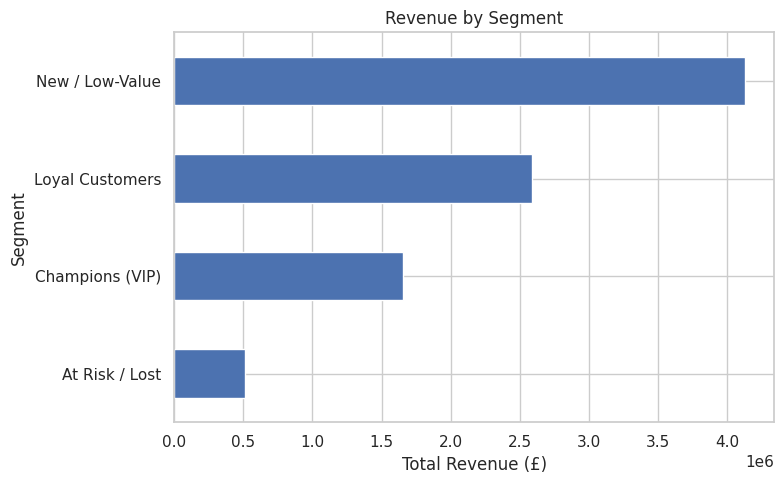

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
summary.sort_values('Total_Revenue').plot(kind='barh', y='Total_Revenue', ax=ax, legend=False)
ax.set_xlabel('Total Revenue (£)')
ax.set_title('Revenue by Segment')
plt.tight_layout()
plt.savefig('../assets/revenue_by_segment.png', dpi=120)
plt.show()


**Takeaways:**
- **Champions (VIP)** — tiny group, huge spend, very frequent & recent buyers -> exclusive perks, dedicated support.
- **Loyal Customers** — solid recurring revenue -> loyalty programs, bundle offers.
- **New / Low-Value** — moderate recency, low spend so far -> nurture with onboarding offers.
- **At Risk / Lost** — haven't purchased in a long time -> win-back campaigns before they churn for good.


In [12]:
rfm.to_csv('../data/processed/customer_segments.csv', index=False)
summary.to_csv('../data/processed/segment_summary.csv')
print('Saved.')


Saved.
